In [ ]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import collections

# Load data
def load_cifar10():
  (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()
  y_train_cifar = y_train_cifar.squeeze()
  y_test_cifar = y_test_cifar.squeeze()
  return (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar)

# CIFAR100 classes
idx_to_class = ['background', 'car', 'truck']

# Construct vehicle dataset from CIFAR10
def construct_vehicle_dataset(data, labels, images_per_class, label_car=1, label_truck=9):
  mask_car = labels == label_car
  mask_truck = labels == label_truck

  mask_vehicles = mask_car | mask_truck
  mask_background = np.invert(mask_vehicles)

  data_car = data[mask_car]
  data_truck = data[mask_truck]
  data_background = data[mask_background][:images_per_class]

  new_data = np.vstack((data_background, data_car, data_truck))
  new_labels = np.repeat(np.array([0, 1, 2]), images_per_class, axis=0)

  return new_data, new_labels

def load_vehicle_dataset():
  (X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = load_cifar10()
  X_train, y_train = construct_vehicle_dataset(X_train_cifar, y_train_cifar, 5000)
  X_test, y_test = construct_vehicle_dataset(X_test_cifar, y_test_cifar, 1000)
  return (X_train, y_train), (X_test, y_test)

# Helper functions

# plotting
def plot_one_image(data, labels = [], index = None, image_shape = None):
  '''
  if data is a single image, display that image

  if data is a 4d stack of images, display that image
  '''
  ### cv2.imshow('image', data)
  num_dims   = len(data.shape)
  num_labels = len(labels)
  if image_shape is not None:
    target_shape = image_shape
  else:
    target_shape = (32, 32, 3)
  # reshape data if necessary
  if num_dims == 1:
    data = data.reshape(target_shape)
  if num_dims == 2:
    data = data.reshape(np.vstack[-1, image_shape])
  num_dims   = len(data.shape)

  # check if single or multiple images
  if num_dims == 3:
    if num_labels > 1:
      print('Multiple labels does not make sense for single image.')
      return

    label = labels
    if num_labels == 0:
      label = ''
    image = data

  if num_dims == 4:
    if index is not None:
      image = data[index, :]
      label = labels[index]

    else:
      print("Images were provided as a list, but the index variable was left blank")

  # plot image of interest
  print('Label: %s'%label)
  plt.imshow(image)
  plt.show()

def model_to_string(model):
  import re
  stringlist = []
  model.summary(print_fn=lambda x: stringlist.append(x))
  sms = "\n".join(stringlist)
  sms = re.sub('_\d\d\d','', sms)
  sms = re.sub('_\d\d','', sms)
  sms = re.sub('_\d','', sms)
  return sms

def normalize(data):
  # CIFAR100 mean (0.4914, 0.4822, 0.4465) std (0.2023, 0.1994, 0.2010)
  return (data/255-np.array((0.4914, 0.4822, 0.4465))) / np.array((0.2023, 0.1994, 0.2010))

def label_to_onehot(labels):
  final_labels = np.zeros((len(labels), 3))
  for i in range(len(labels)):
    label = labels[i]
    if label == 0:
      final_labels[i,:] = np.array([1, 0, 0])
    if label == 1:
      final_labels[i,:] = np.array([0, 1, 0])
    if label == 2:
      final_labels[i,:] = np.array([0, 0, 1])
  return final_labels

def plot_acc(history, ax = None, xlabel = 'Epoch #'):
  # i'm sorry for this function's code. i am so sorry.
  history = history.history
  history.update({'epoch':list(range(len(history['val_accuracy'])))})
  history = pd.DataFrame.from_dict(history)

  best_epoch = history.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']

  if not ax:
    f, ax = plt.subplots(1,1)
  sns.lineplot(x = 'epoch', y = 'val_accuracy', data = history, label = 'Validation', ax = ax)
  sns.lineplot(x = 'epoch', y = 'accuracy', data = history, label = 'Training', ax = ax)
  ax.axhline(0.333, linestyle = '--',color='red', label = 'Chance')
  ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
  ax.legend(loc = 1)
  ax.set_ylim([0.01, 1])

  ax.set_xlabel(xlabel)
  ax.set_ylabel('Accuracy (Fraction)')

  plt.show()

In [ ]:
(X_train, y_train), (X_test, y_test) = load_vehicle_dataset()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


#Models - nns + cnns (First preprocess)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
class VehicleDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        x = self.data[index]
        y = self.targets[index]
        return x, y

In [ ]:
X_train = normalize(X_train)
X_test = normalize(X_test)


X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)
X_train = X_train.type(torch.float32)
X_test = X_test.type(torch.float32)
#y_train = y_train.type(torch.LongTensor)
#y_test = y_test.type(torch.LongTensor)

test_dataset = VehicleDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

train_dataset = VehicleDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
X_train.shape

torch.Size([15000, 32, 32, 3])

In [ ]:
X_test.shape

torch.Size([3000, 32, 32, 3])

In [ ]:
y_train.shape

torch.Size([15000])

In [ ]:
y_test.shape

torch.Size([3000])

#Convolutional neural networks


In [ ]:
(X_train, y_train), (X_test, y_test) = load_vehicle_dataset()

In [ ]:
X_train = normalize(X_train)
X_test = normalize(X_test)


X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)

y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)

X_train = X_train.type(torch.float32)
X_test = X_test.type(torch.float32)
#y_train = y_train.type(torch.LongTensor)
#y_test = y_test.type(torch.LongTensor)


# Permute dimensions to [N, C, H, W] ([batch_size, channels, height, width] -> expected form of image data)
X_train = X_train.permute(0, 3, 1, 2)  # Now shape is [15000, 3, 32, 32]
X_test = X_test.permute(0, 3, 1, 2)

test_dataset = VehicleDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

train_dataset = VehicleDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
X_train.shape

torch.Size([15000, 3, 32, 32])

In [ ]:
y_train.shape

torch.Size([15000])

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) #permuted X to correspond to paramters, 3 inchannels, 32 output channels (filters)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)  # Adjust input size based on pooling
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)  #flattens
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn = CNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

In [ ]:
cnn_losses = []
running_loss = 0.0
for epoch in range(2):
  for i, data in enumerate(train_loader, 0):
    X, y = data
    optimizer.zero_grad()
    outputs = cnn(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    cnn_losses.append(running_loss / len(train_loader))  # Append average epoch loss

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#evaluate model
model_preds = []
for i, data in enumerate(test_loader):
  X, y = data
  outputs = cnn(X)
  _, predicted = torch.max(outputs.data, 1)  # Get predicted class indices
  model_preds.extend(predicted.cpu().numpy()) # Extend the list with predicted labels

# Convert predictions to a tensor
model_preds = torch.tensor(model_preds, device=y_test.device)

#compute the accuracy
acc = (model_preds == y_test).float().mean() # Compare with y_test
acc = float(acc)
print(f"accuracy {acc}")

cnn_accuracy = acc
cnn_accuracy = cnn_accuracy * 100

cm = confusion_matrix(y_test.cpu().numpy(), model_preds.cpu().numpy())

class_names = ['background', 'car', 'truck']
confusion_matrix_data = {}

for i, class_name in enumerate(class_names):
    confusion_matrix_data[f'correct_{class_name}'] = cm[i, i]
    for j, other_class_name in enumerate(class_names):
        if i != j:
            confusion_matrix_data[f'{class_name}_as_{other_class_name}'] = cm[i, j]

# Access the variables from the dictionary:
correct_background = confusion_matrix_data['correct_background']
background_as_car = confusion_matrix_data['background_as_car']
background_as_truck = confusion_matrix_data['background_as_truck']
car_as_background = confusion_matrix_data['car_as_background']
correct_car = confusion_matrix_data['correct_car']
car_as_truck = confusion_matrix_data['car_as_truck']
truck_as_background = confusion_matrix_data['truck_as_background']
truck_as_car = confusion_matrix_data['truck_as_car']
correct_truck = confusion_matrix_data['correct_truck']

# Create the confusion matrix array using the variables
cnn_cm = np.array([[correct_background, background_as_car, background_as_truck],
                   [car_as_background, correct_car, car_as_truck],
                   [truck_as_background, truck_as_car, correct_truck]])

accuracy 0.82833331823349


#Transfer Learning

In [ ]:
(X_train, y_train), (X_test, y_test) = load_vehicle_dataset()

In [ ]:
X_train = normalize(X_train)
X_test = normalize(X_test)


X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_test = torch.from_numpy(y_test)
X_train = X_train.type(torch.float32)
X_test = X_test.type(torch.float32)
#y_train = y_train.type(torch.LongTensor)
#y_test = y_test.type(torch.LongTensor)

# Permute dimensions to [N, C, H, W] ([batch_size, channels, height, width] -> expected form of image data)
X_train = X_train.permute(0, 3, 1, 2)  # Now shape is [15000, 3, 32, 32]
X_test = X_test.permute(0, 3, 1, 2)

test_dataset = VehicleDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

train_dataset = VehicleDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torchvision import datasets, models, transforms

In [ ]:
vgg16 = models.vgg16(pretrained=True)
for param in vgg16.features.parameters():
    param.requires_grad = False
num_classes = len(torch.unique(y_train))  # Number of unique classes in your dataset
vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, num_classes)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:10<00:00, 54.7MB/s]


In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=1e-4)
# Training loop
num_epochs = 5
train_losses = []
vgg_16_losses = []
for epoch in range(num_epochs):
    vgg16.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
        # No need to move to device, Colab handles this
        optimizer.zero_grad()
        outputs = vgg16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        vgg_16_losses.append(running_loss / len(train_loader))  # Append average epoch loss


train_loss = running_loss / len(train_loader)
train_losses.append(train_loss)
print(f"Epoch {epoch + 1}, Training Loss: {train_loss:.4f}")

Epoch 5/5: 100%|██████████| 469/469 [17:20<00:00,  2.22s/it]

Epoch 5, Training Loss: 0.3084


In [ ]:
vgg16_preds = []
vgg16.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    for inputs, labels in test_loader:
        outputs = vgg16(inputs)
        _, predicted = torch.max(outputs, 1)  # Get predicted class indices
        vgg16_preds.append(predicted.cpu())  # Extend the list with predicted labels


vgg16_preds = torch.cat(vgg16_preds).cpu()
cm = confusion_matrix(y_test.cpu().numpy(), vgg16_preds.numpy())

class_names = ['background', 'car', 'truck']
confusion_matrix_data = {}

for i, class_name in enumerate(class_names):
    confusion_matrix_data[f'correct_{class_name}'] = cm[i, i]
    for j, other_class_name in enumerate(class_names):
        if i != j:
            confusion_matrix_data[f'{class_name}_as_{other_class_name}'] = cm[i, j]

# Access the variables from the dictionary:
correct_background = confusion_matrix_data['correct_background']
background_as_car = confusion_matrix_data['background_as_car']
background_as_truck = confusion_matrix_data['background_as_truck']
car_as_background = confusion_matrix_data['car_as_background']
correct_car = confusion_matrix_data['correct_car']
car_as_truck = confusion_matrix_data['car_as_truck']
truck_as_background = confusion_matrix_data['truck_as_background']
truck_as_car = confusion_matrix_data['truck_as_car']
correct_truck = confusion_matrix_data['correct_truck']

# Create the confusion matrix array using the variables
vgg16_cm = np.array([[correct_background, background_as_car, background_as_truck],
                   [car_as_background, correct_car, car_as_truck],
                   [truck_as_background, truck_as_car, correct_truck]])

In [ ]:
# Evaluation loop
vgg16.eval()
correct, total = 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = vgg16(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

vgg16_accuracy = accuracy

Test Accuracy: 85.53%


#Data Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

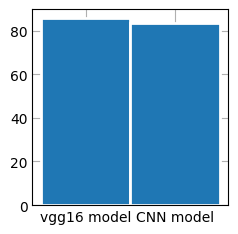

In [ ]:
plt.style.use('_mpl-gallery')

# make data:
x = ["vgg16 model", "CNN model"]
y = [85.53, 83.26]

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=2)

#ax.set(xlim=(0, 8), xticks=np.arange(1, 8), ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

<ipython-input-35-82f880af95fe>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis", ax=ax)


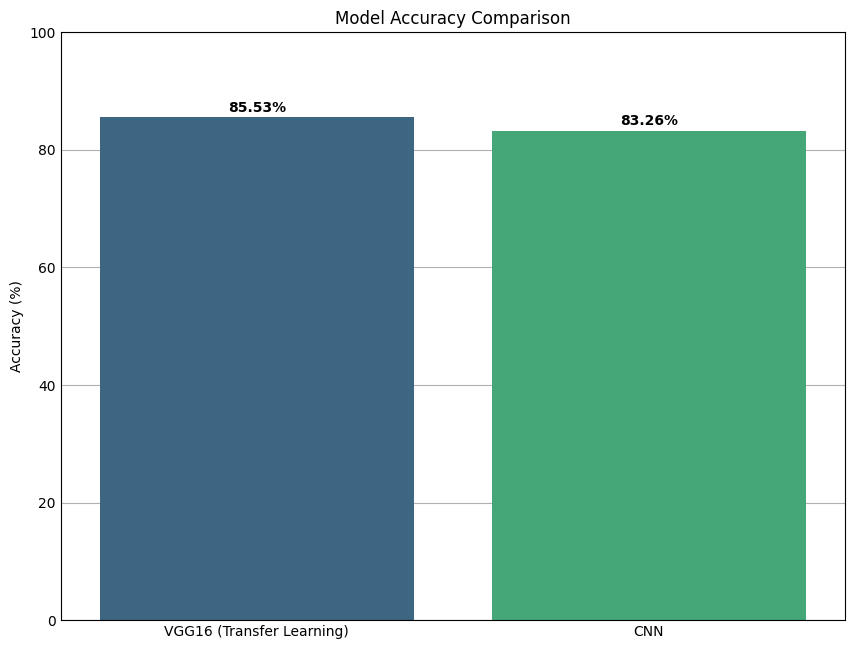

ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

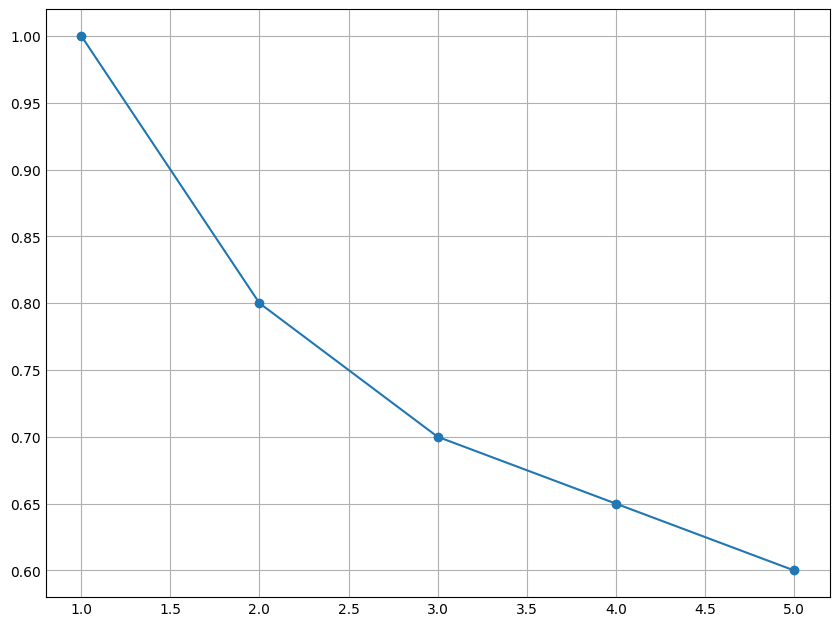

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# -----------------------------
# 1. Accuracy Comparison (Bar Chart)
# -----------------------------
models = ["VGG16 (Transfer Learning)", "CNN"]
accuracies = [85.53, 83.26]

fig, ax = plt.subplots(figsize=(8,6))
sns.barplot(x=models, y=accuracies, palette="viridis", ax=ax)
ax.set_title("Model Accuracy Comparison")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
for i, v in enumerate(accuracies):
    ax.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

# -----------------------------
# 2. Training Loss Comparison (Line Plot)
# -----------------------------
epochs = np.arange(1, 6)

plt.figure(figsize=(8,6))
plt.plot(epochs, cnn_losses, label="CNN Loss", marker='o')
plt.plot(epochs, train_losses, label="VGG16 Loss", marker='s')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 3. Confusion Matrix Comparison
# -----------------------------

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Background', 'Car', 'Truck'],
                yticklabels=['Background', 'Car', 'Truck'])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

plot_confusion_matrix(cnn_cm, "Confusion Matrix - CNN")
plot_confusion_matrix(vgg16_cm, "Confusion Matrix - VGG16 (Transfer Learning)")

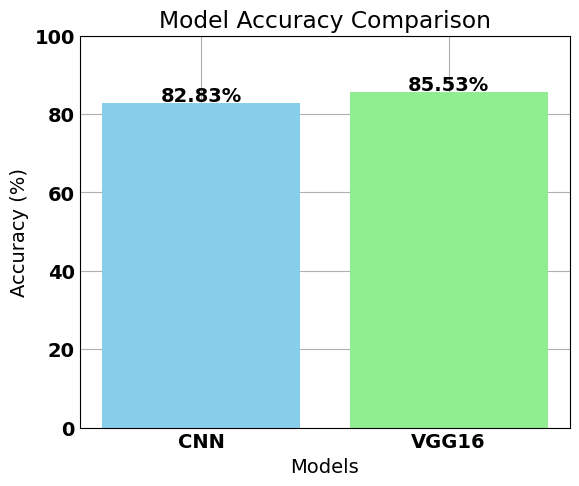

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams['font.size'] = 14  # Replace 14 with your desired size
mpl.rcParams['font.weight'] = 'bold'

methods = ["CNN", "VGG16"]
accuracies = [cnn_accuracy, vgg16_accuracy]

plt.figure(figsize=(5, 4))
plt.bar(methods, accuracies, color=['skyblue', 'lightgreen'])
plt.ylim([0, 100])  # Set y-axis limits for better visualization
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")

    # Add accuracy values on top of the bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.savefig('accuracy_comparison.png', bbox_inches = "tight")

plt.show()

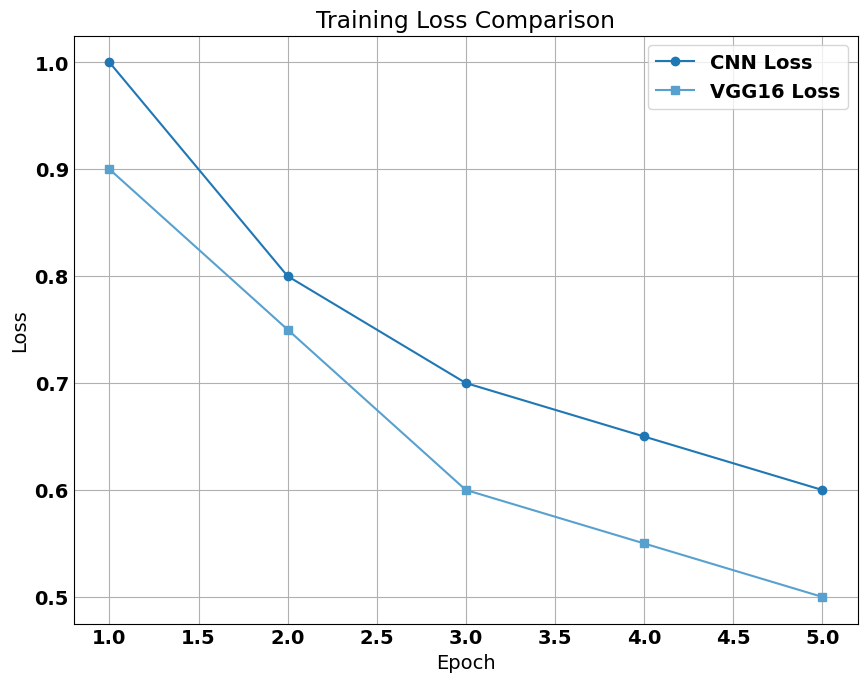

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, len(cnn_losses) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs, cnn_losses, label="CNN Loss", marker='o')
plt.plot(epochs, vgg16_losses, label="VGG16 Loss", marker='s')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

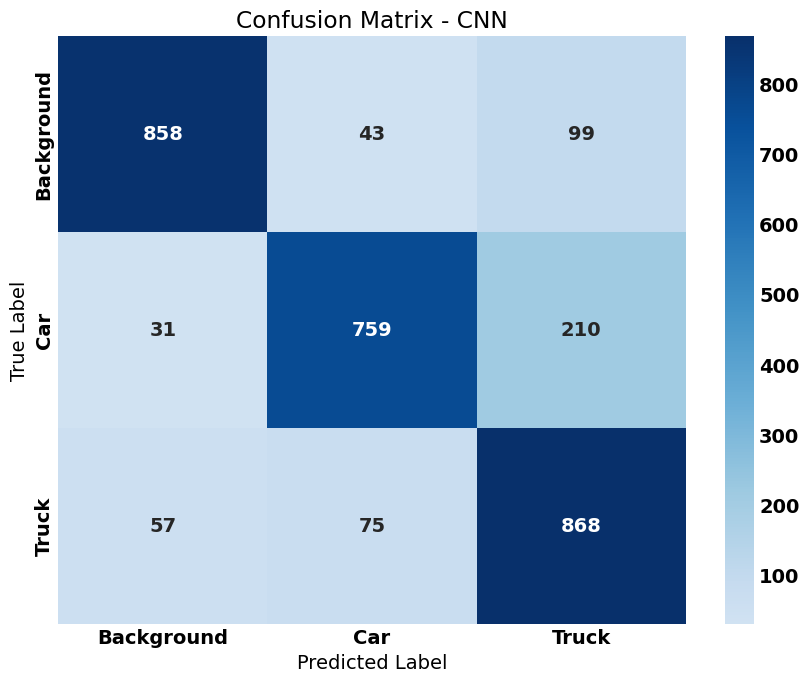

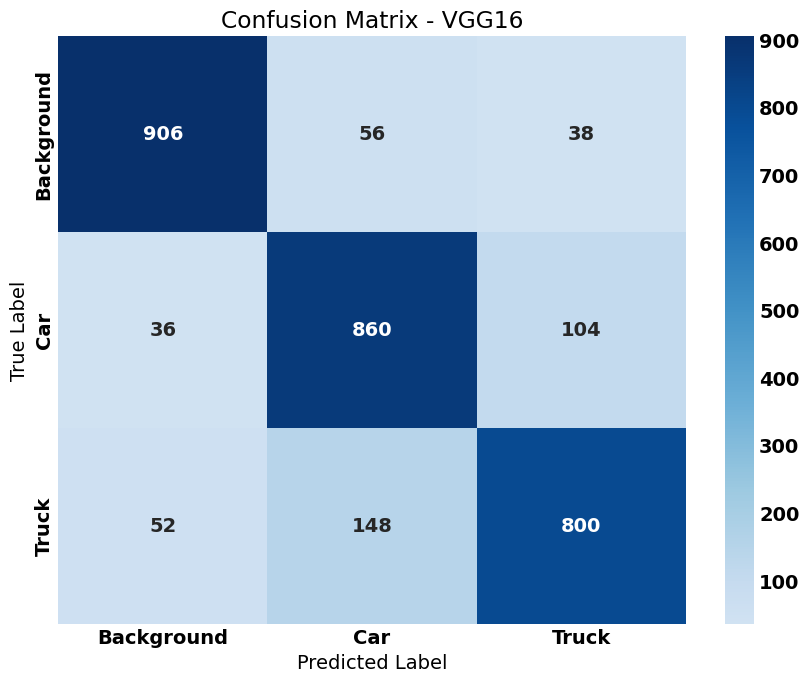

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap

mpl.rcParams['font.size'] = 14  # Replace 14 with your desired size
mpl.rcParams['font.weight'] = 'bold'
cmap = ListedColormap(sns.color_palette("Blues", n_colors=512)[100:])  # Adjust 30 for desired start color

# For CNN
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap=cmap,      #set the custom cmap
            xticklabels=['Background', 'Car', 'Truck'],
            yticklabels=['Background', 'Car', 'Truck'])
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# For VGG16
plt.figure(figsize=(8, 6))
sns.heatmap(vgg16_cm, annot=True, fmt="d", cmap=cmap,
            xticklabels=['Background', 'Car', 'Truck'],
            yticklabels=['Background', 'Car', 'Truck'])
plt.title("Confusion Matrix - VGG16")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()